In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 


In [ ]:
df = pd.read_csv('MushroomDataset/secondary_data.csv', delimiter=';')

df.info()
df.describe()
df.groupby('class').describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-surface           46949 non-null  object 
 4   cap-color             61069 non-null  object 
 5   does-bruise-or-bleed  61069 non-null  object 
 6   gill-attachment       51185 non-null  object 
 7   gill-spacing          36006 non-null  object 
 8   gill-color            61069 non-null  object 
 9   stem-height           61069 non-null  float64
 10  stem-width            61069 non-null  float64
 11  stem-root             9531 non-null   object 
 12  stem-surface          22945 non-null  object 
 13  stem-color            61069 non-null  object 
 14  veil-type             3177 non-null   object 
 15  veil-color         

cap-diameter                                                     \
             count      mean       std   min   25%   50%   75%    max   
class                                                                   
e          27181.0  7.798696  6.373404  0.53  4.29  6.71  9.41  62.34   
p          33888.0  5.879763  3.966391  0.38  3.04  4.98  7.85  30.34   

      stem-height            ...              stem-width             \
            count      mean  ...   75%    max      count       mean   
class                        ...                                      
e         27181.0  7.039077  ...  7.74  33.92    27181.0  14.361084   
p         33888.0  6.214554  ...  7.74  20.19    33888.0  10.375463   

                                                    
             std   min   25%    50%    75%     max  
class                                               
e      11.042703  0.74  7.13  12.59  18.39  103.91  
p       8.753975  0.00  3.58   7.66  14.34   58.95  

[2 rows x 24 columns]

In [4]:
df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w


In [21]:
pd.DataFrame({
    "attribute": df.columns,
    "dtype": df.dtypes,
    "n_unique": df.nunique(),
    "Missing": df.isnull().sum(),
    "Usable": df.apply(lambda x: "Yes" if x.name != 'class' and x.isnull().sum()/x.shape[0] < 0.6 else "No")
})  

,attribute,dtype,n_unique,Missing,Usable
class,class,object,2,0,No
cap-diameter,cap-diameter,float64,2571,0,Yes
cap-shape,cap-shape,object,7,0,Yes
cap-surface,cap-surface,object,11,14120,Yes
cap-color,cap-color,object,12,0,Yes
does-bruise-or-bleed,does-bruise-or-bleed,object,2,0,Yes
gill-attachment,gill-attachment,object,7,9884,Yes
gill-spacing,gill-spacing,object,3,25063,Yes
gill-color,gill-color,object,12,0,Yes
stem-height,stem-height,float64,2226,0,Yes


veil-type is only one value "u" and has records in both p and e classes. drop variable for no value??

In [17]:
df['class_num'] = df['class'].map({'e': 0, 'p': 1}) # 1=poisounous, 0=edible
categorical_columns = df.select_dtypes(include=['object']).columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

numeric values are all right skewed

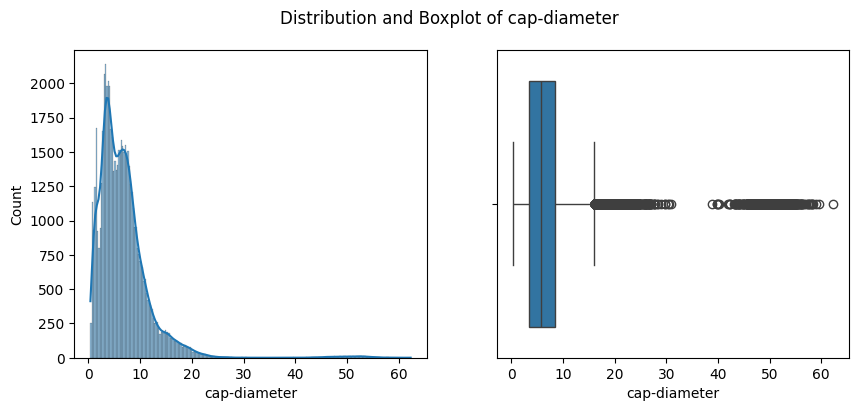

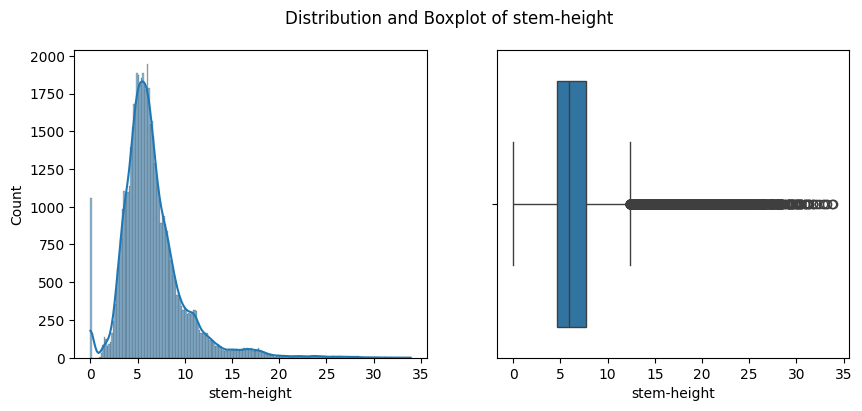

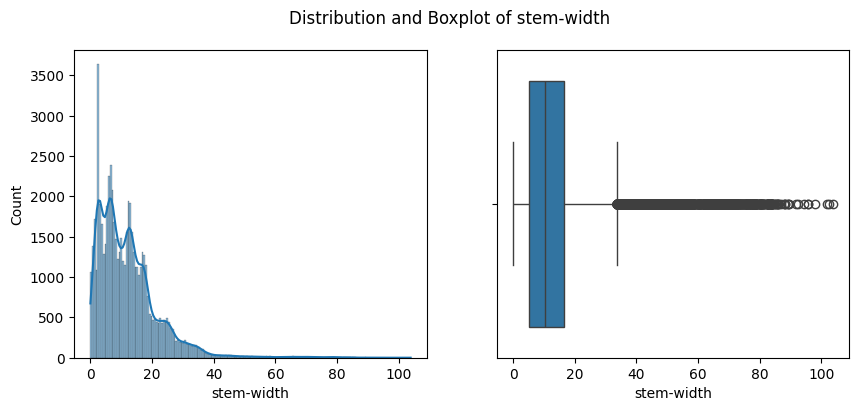

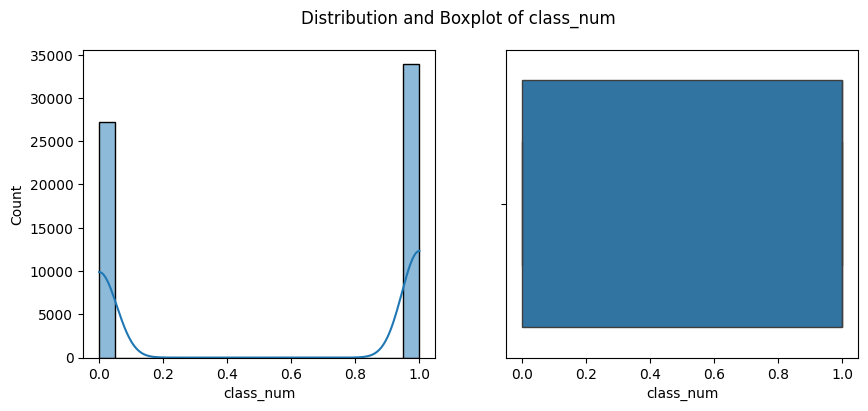

In [18]:
for col in numerical_columns:
    fig, ax = plt.subplots(1,2, figsize=(10,4))
    sns.histplot(df[col], kde=True, ax=ax[0])
    sns.boxplot(x=df[col], ax=ax[1])
    plt.suptitle(f'Distribution and Boxplot of {col}')
    plt.show()

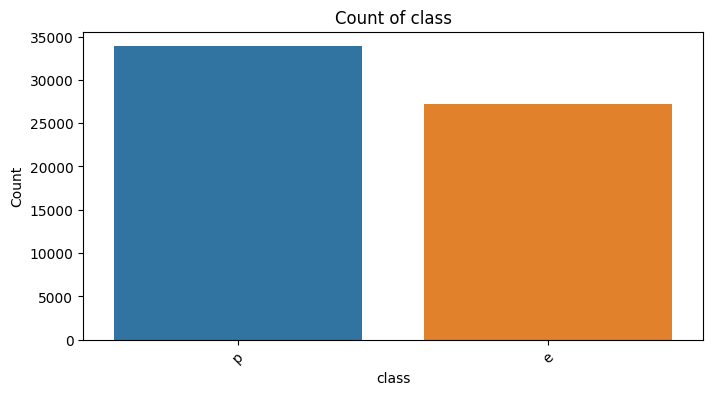

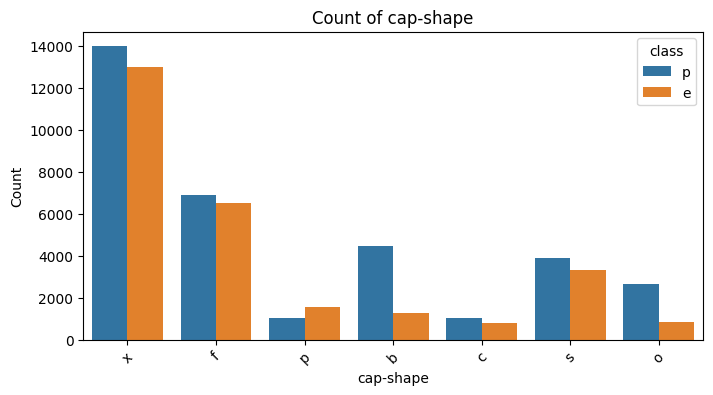

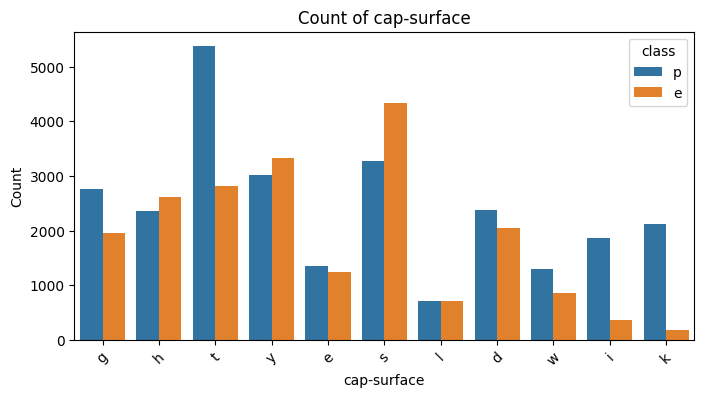

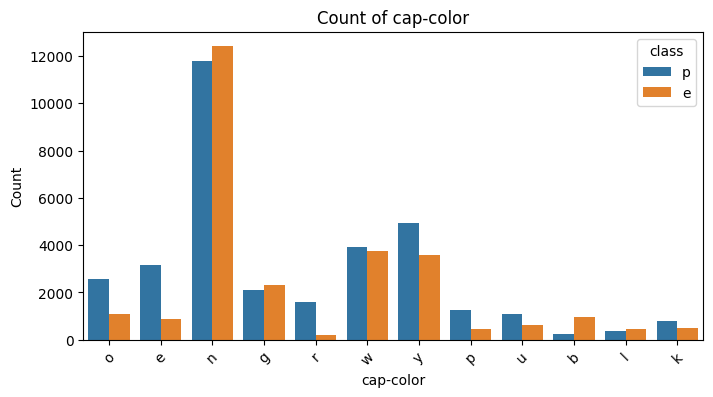

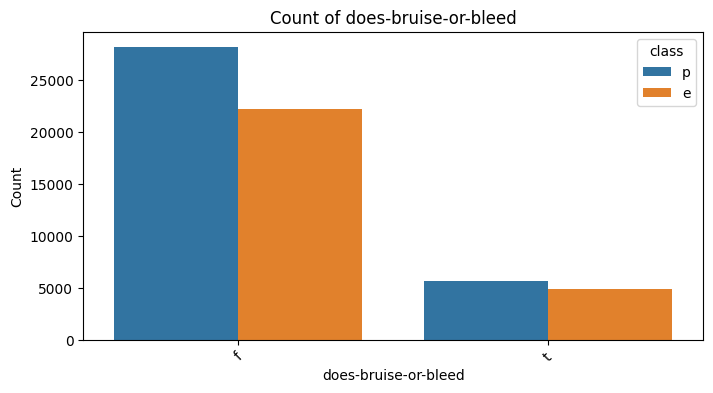

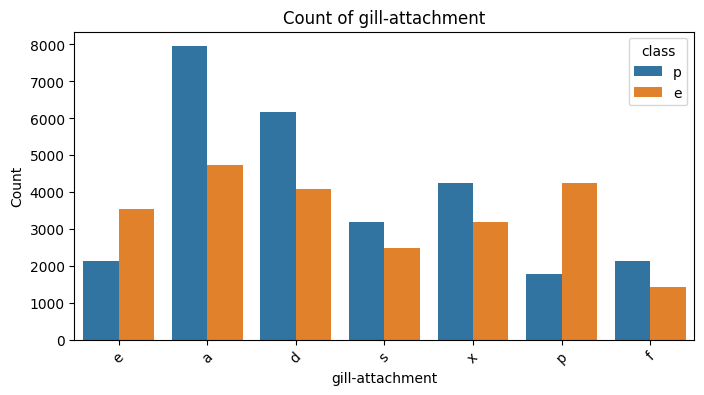

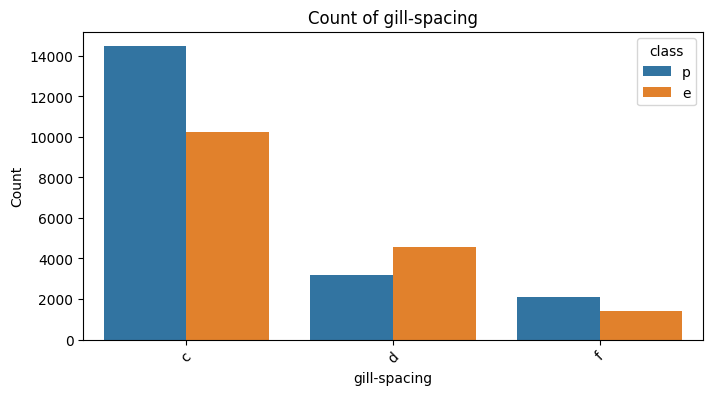

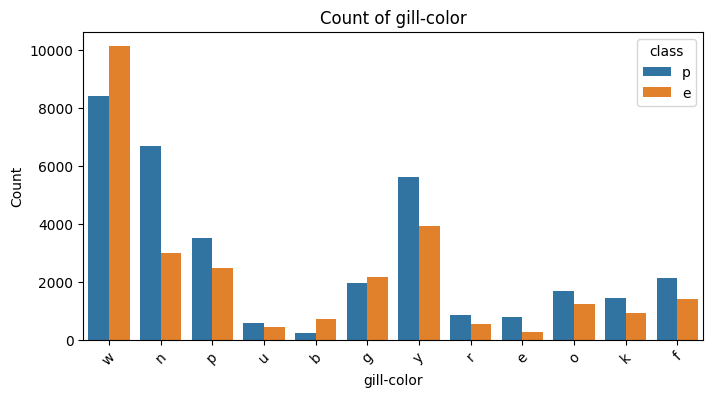

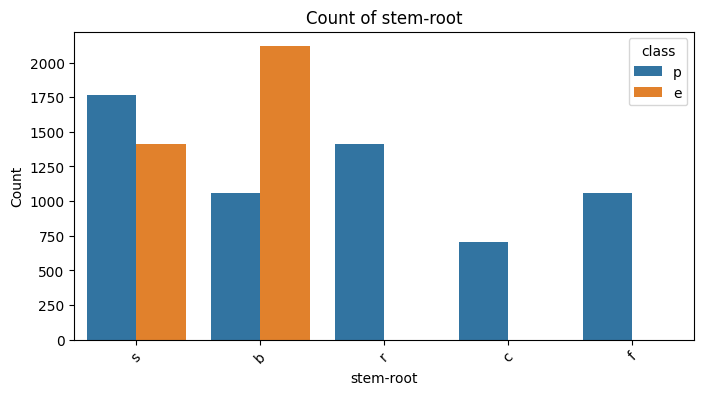

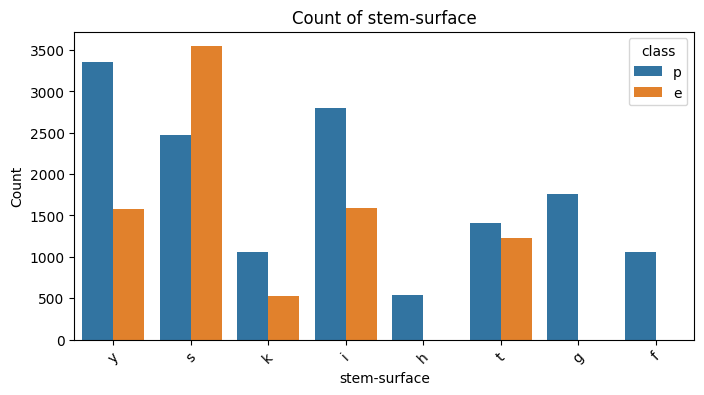

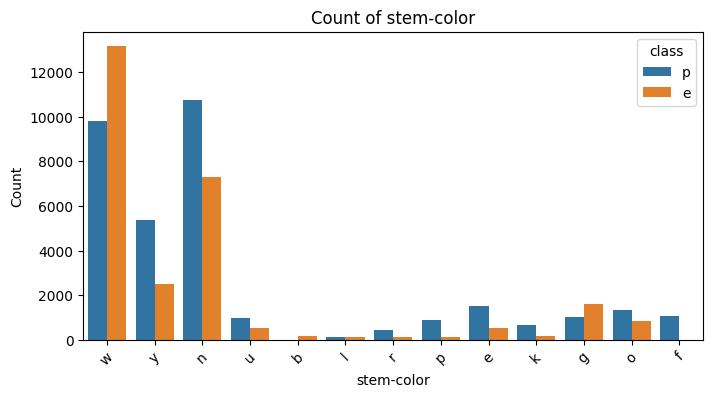

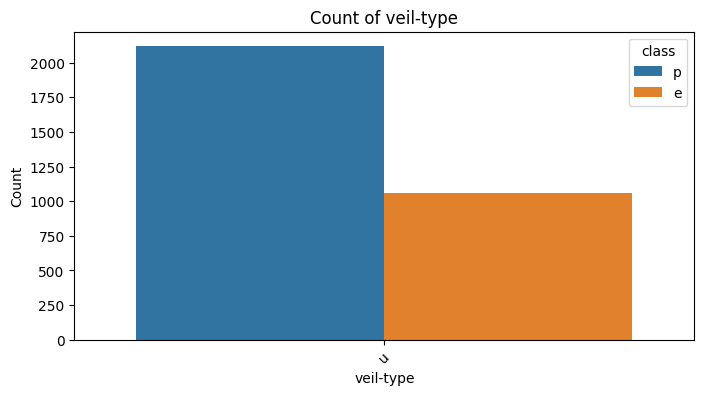

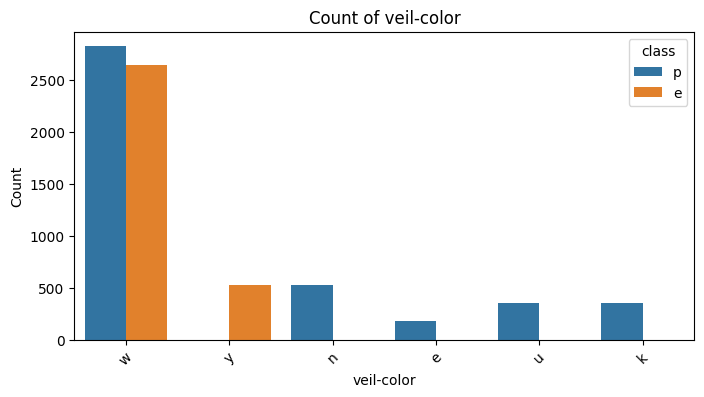

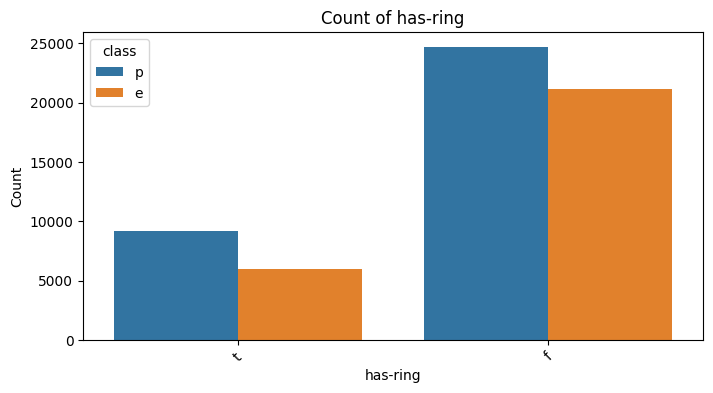

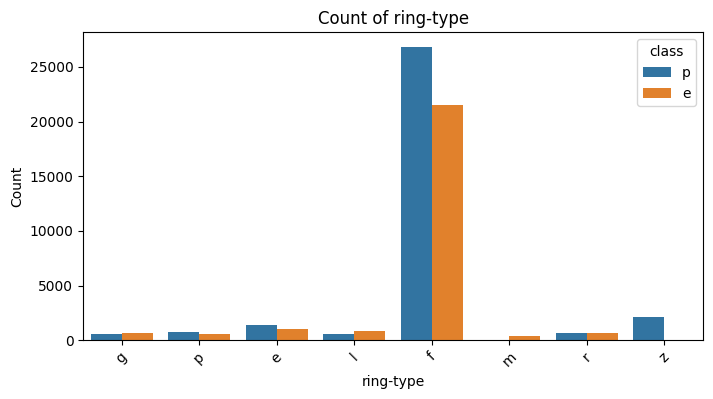

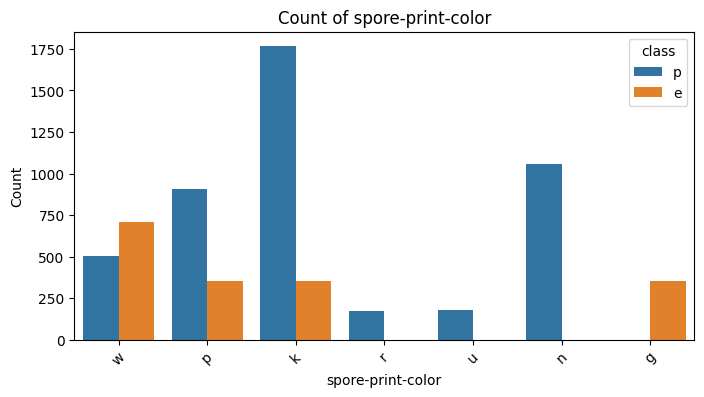

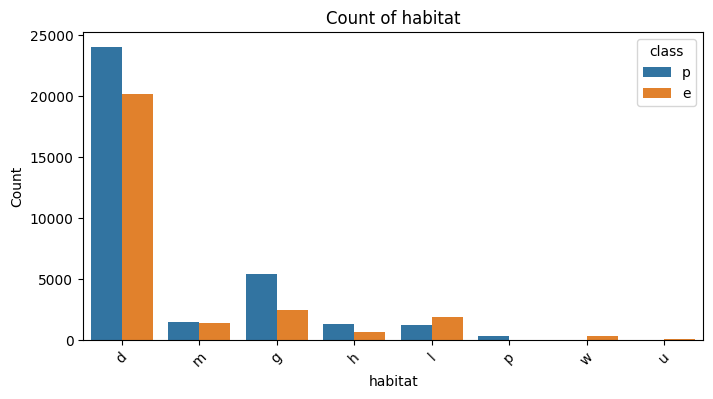

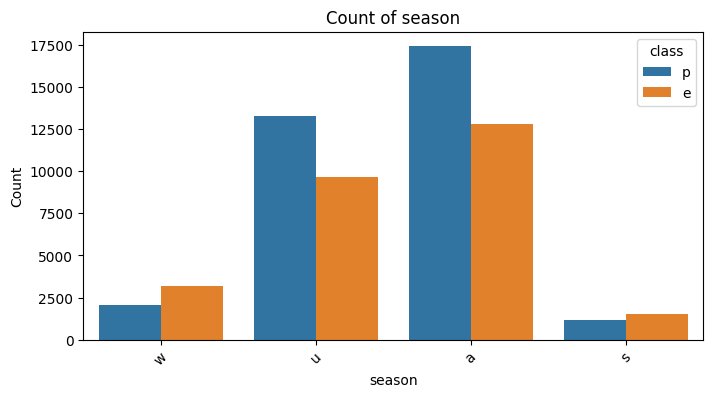

In [43]:
for col in categorical_columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, data=df, hue = 'class')
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

2.6 Visualize relationships between attributes

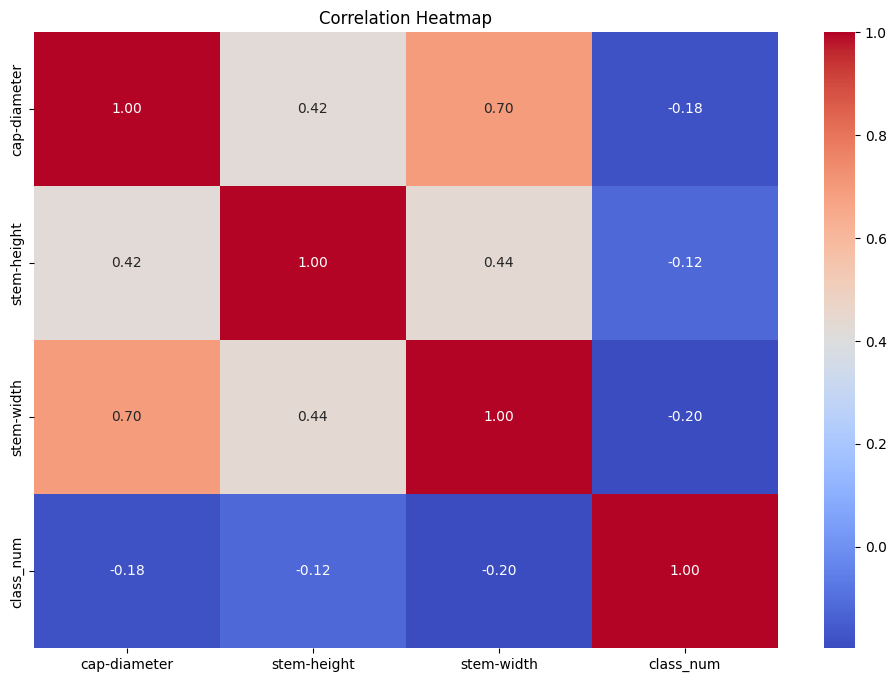

In [19]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df[numerical_columns].corr(),
    cmap='coolwarm',
    annot=True,
    fmt='.2f'
)
plt.title("Correlation Heatmap")
plt.show()

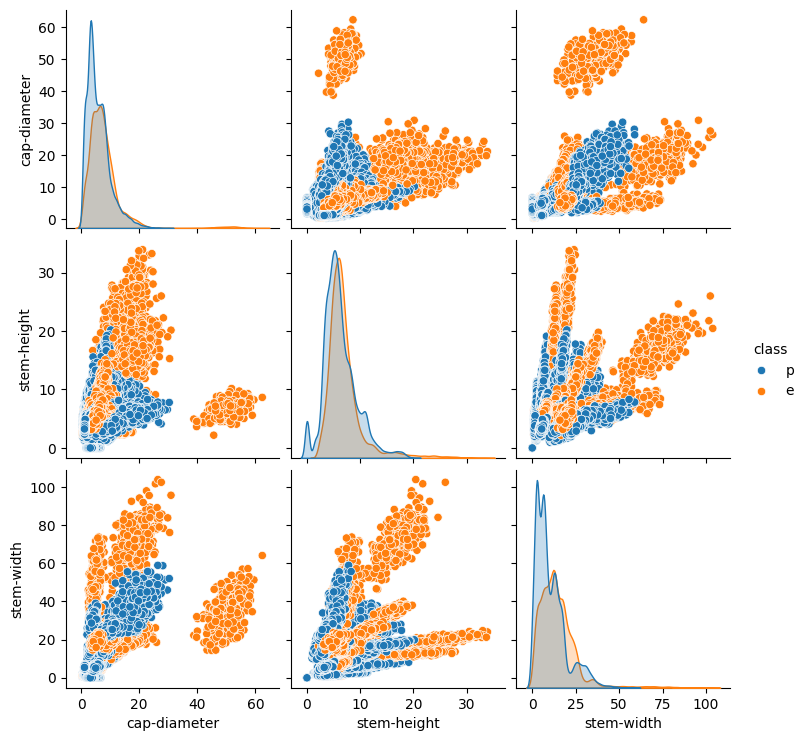

In [57]:
sns.pairplot(df, hue='class')

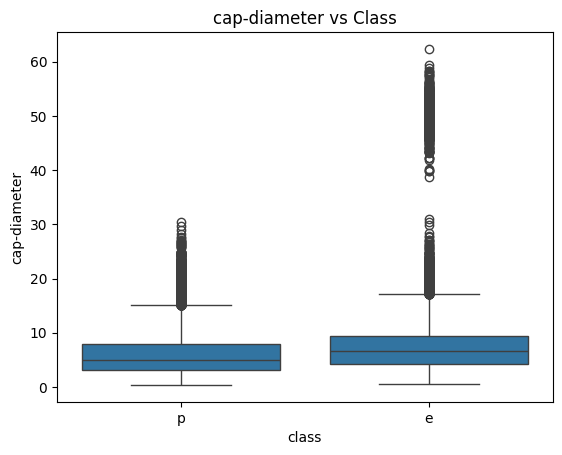

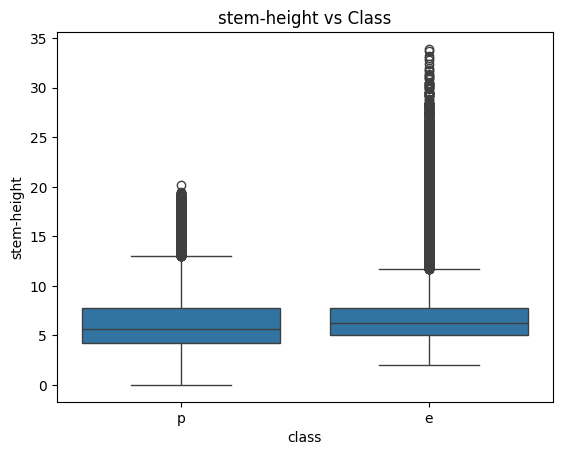

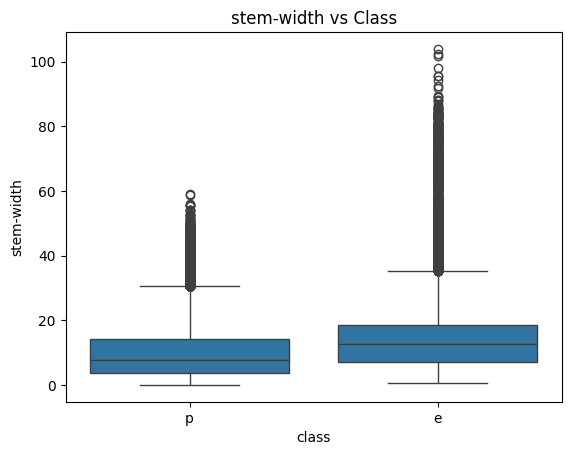

In [59]:
for col in df[numerical_columns].columns: 
    sns.boxplot(x="class", y=col, data=df)
    plt.title(f"{col} vs Class")
    plt.show()


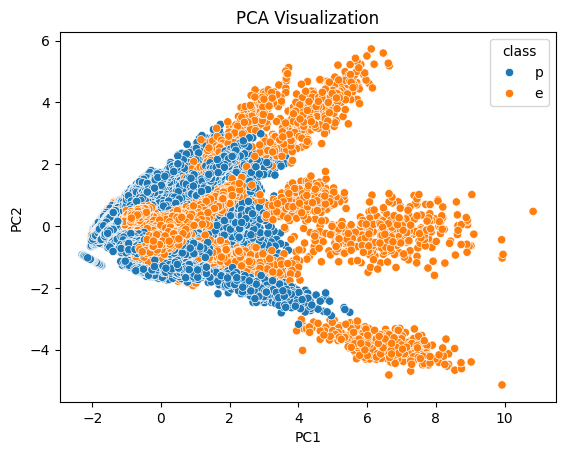

In [66]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df.drop("class", axis=1)[numerical_columns]
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(components, columns=["PC1","PC2"])
pca_df["class"] = df["class"]

sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="class")
plt.title("PCA Visualization")
plt.show()


